Emotion detection module for the COS30082 facial recognition project. MobileNetV2 with ImageNet-pretrained weights is fine-tuned on FER-2013 using a two-phase transfer-learning recipe. All reusable logic lives in the importable Python modules under src; this notebook orchestrates them and produces the plots used in the report.

Mount Google Drive, clone the repo, and install dependencies. Drive holds the dataset and trained weights; the repo holds the source code; the Colab VM is the temporary runtime that brings them together.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content
![ -d COS30082-Facial-Recognition ] || git clone https://github.com/jeromeliao03/COS30082-Facial-Recognition.git
%cd /content/COS30082-Facial-Recognition
!git fetch origin && git checkout emotion-branch && git pull --ff-only

/content
Cloning into 'COS30082-Facial-Recognition'...
remote: Enumerating objects: 305, done.
remote: Counting objects: 100% (242/242), done.
remote: Compressing objects: 100% (188/188), done.
remote: Total 305 (delta 96), reused 181 (delta 51), pack-reused 63 (from 1)
Receiving objects: 100% (305/305), 111.00 MiB | 15.55 MiB/s, done.
Resolving deltas: 100% (105/105), done.
/content/COS30082-Facial-Recognition
Branch 'emotion-branch' set up to track remote branch 'emotion-branch' from 'origin'.
Switched to a new branch 'emotion-branch'
Already up to date.


In [3]:
!pip install -q -r emotion/requirements.txt

In [4]:
import sys
REPO_ROOT = '/content/COS30082-Facial-Recognition'
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import tensorflow as tf
print('tf', tf.__version__,
      '| GPU:', tf.config.list_physical_devices('GPU') or 'CPU only')

tf 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Download FER-2013 from Kaggle into Drive. Runs once per Drive — subsequent sessions skip the download. Requires a Kaggle API token uploaded to the Drive root beforehand.

In [5]:
import os, shutil, pathlib
from emotion.src import config as C

DATA_DIR = pathlib.Path(C.DATA_DIR)
DATA_DIR.parent.mkdir(parents=True, exist_ok=True)
C.MODELS_DIR.mkdir(parents=True, exist_ok=True)
C.REPORTS_DIR.mkdir(parents=True, exist_ok=True)

if not (DATA_DIR / 'train').exists():
    src = '/content/drive/MyDrive/MLGroup/kaggle.json'
    os.makedirs('/root/.kaggle', exist_ok=True)
    shutil.copy(src, '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)

    !kaggle datasets download -d msambare/fer2013 -p /content --unzip
    shutil.move('/content/train', str(DATA_DIR / 'train'))
    shutil.move('/content/test',  str(DATA_DIR / 'test'))
    print('Dataset extracted to', DATA_DIR)
else:
    print('Dataset already on Drive:', DATA_DIR)

print('train classes:', sorted(os.listdir(DATA_DIR / 'train')))
print('test  classes:', sorted(os.listdir(DATA_DIR / 'test')))

Dataset already on Drive: /content/drive/MyDrive/MLGroup/emotion/data/fer2013
train classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
test  classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


Copy the dataset from Drive to the Colab VM's local SSD. The Drive FUSE mount is very slow for many small files, which makes training read-bound. Copying once at the start of the session lets ImageDataGenerator read from local disk, which is roughly two orders of magnitude faster. The local copy disappears when Colab disconnects; the Drive copy is untouched.

In [6]:
import shutil, pathlib
from emotion.src import config as C

LOCAL_DATA = pathlib.Path('/content/fer2013')

if not LOCAL_DATA.exists():
    print('Copying FER-2013 from Drive to local SSD (one-off, ~2 min)...')
    shutil.copytree(C.DATA_DIR, LOCAL_DATA)
    print('Done.')
else:
    print('Local dataset already present.')

# Point the config at the local copy for this session. Models and reports
# still write to Drive via C.MODELS_DIR / C.REPORTS_DIR.
C.DATA_DIR = LOCAL_DATA
C.TRAIN_DIR = LOCAL_DATA / 'train'
C.TEST_DIR = LOCAL_DATA / 'test'
print('TRAIN_DIR ->', C.TRAIN_DIR)
print('TEST_DIR  ->', C.TEST_DIR)

Copying FER-2013 from Drive to local SSD (one-off, ~2 min)...
Done.
TRAIN_DIR -> /content/fer2013/train
TEST_DIR  -> /content/fer2013/test


Class distribution and a grid of sample images. FER-2013 is heavily imbalanced — disgust has roughly thirteen times fewer images than happy. This imbalance is accepted rather than corrected because it mirrors real-world emotion frequency in workplace and attendance contexts. Weighting the loss would raise minority-class recall at the cost of precision, which is the wrong trade-off when false-positive readings are more costly than missed ones.

{'angry': 3995, 'disgust': 436, 'fear': 4097, 'happy': 7215, 'neutral': 4965, 'sad': 4830, 'surprise': 3171}


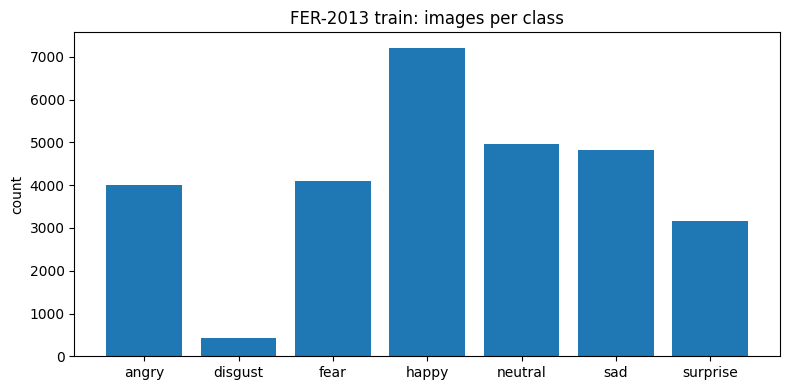

In [7]:
import os, random
import matplotlib.pyplot as plt
from PIL import Image
from emotion.src import config as C

counts = {cls: len(os.listdir(C.TRAIN_DIR / cls)) for cls in C.CLASSES}
print(counts)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(list(counts.keys()), list(counts.values()))
ax.set_title('FER-2013 train: images per class')
ax.set_ylabel('count')
fig.tight_layout(); plt.show()
fig.savefig(C.REPORTS_DIR / 'class_distribution.png', dpi=150)

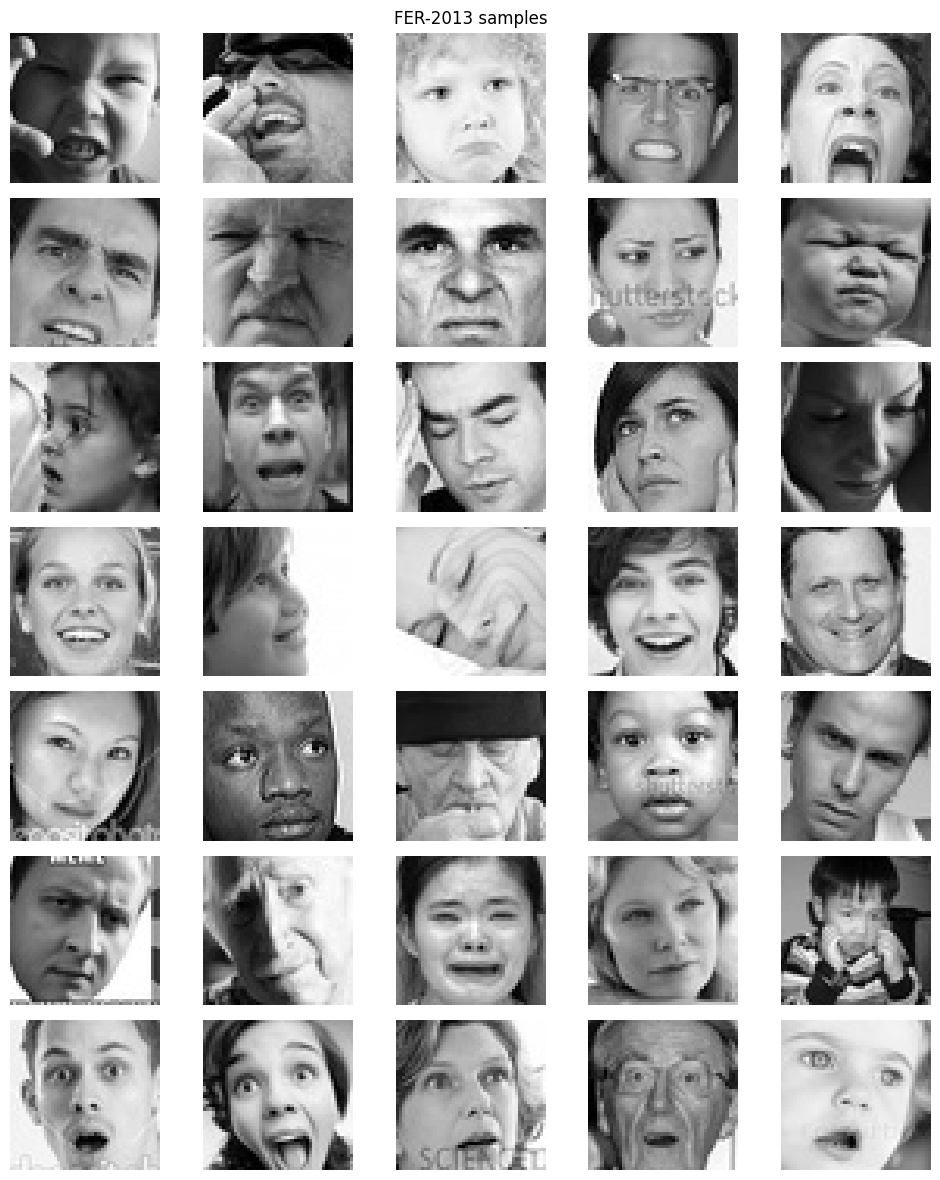

In [8]:
random.seed(0)
fig, axes = plt.subplots(len(C.CLASSES), 5, figsize=(10, 12))
for r, cls in enumerate(C.CLASSES):
    files = os.listdir(C.TRAIN_DIR / cls)
    picks = random.sample(files, 5)
    for c, fn in enumerate(picks):
        img = Image.open(C.TRAIN_DIR / cls / fn)
        axes[r, c].imshow(img, cmap='gray')
        axes[r, c].axis('off')
        if c == 0:
            axes[r, c].set_ylabel(cls, rotation=0, ha='right', va='center')
fig.suptitle('FER-2013 samples'); fig.tight_layout(); plt.show()
fig.savefig(C.REPORTS_DIR / 'sample_grid.png', dpi=150)

Build the training, validation, and test generators. Training applies MobileNetV2 preprocessing (pixels rescaled to negative one through one) and light augmentation including horizontal flip, small rotation, translation, zoom, and brightness jitter. Validation and test use the same preprocessing but no augmentation so the reported metrics are deterministic. Grayscale FER images are auto-triplicated to three channels at load time so they fit the pretrained backbone's expected input shape.

In [9]:
from emotion.src.data import build_dataloaders
train_data, val_data, test_data = build_dataloaders()

print(f'train samples: {train_data.samples}  (batches: {len(train_data)})')
print(f'val   samples: {val_data.samples}  (batches: {len(val_data)})')
print(f'test  samples: {test_data.samples}  (batches: {len(test_data)})')
print('class indices:', train_data.class_indices)

xb, yb = next(train_data)
print('batch x:', xb.shape, xb.dtype, '| min/max:', xb.min(), xb.max())
print('batch y:', yb.shape, yb.dtype, '| sum per row:', yb.sum(axis=1)[:3])

Found 25841 images belonging to 7 classes.
Found 2868 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
train samples: 25841  (batches: 404)
val   samples: 2868  (batches: 45)
test  samples: 7178  (batches: 113)
class indices: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
batch x: (64, 224, 224, 3) float32 | min/max: -1.0 1.0
batch y: (64, 7) float32 | sum per row: [1. 1. 1.]


Build the model. MobileNetV2 is loaded with ImageNet weights and without its original classifier. A global average pooling layer collapses the spatial feature map into a single vector, followed by dropout and a new dense layer with seven outputs and softmax activation. The base model is initially frozen so only the new head trains in the first phase. Calling the base model with training set to false keeps batch-normalisation layers in inference mode, preserving pretrained running statistics during fine-tuning.

In [10]:
from emotion.src.model import build_mobilenetv2, count_trainable
model, base_model = build_mobilenetv2()
trainable, total = count_trainable(model)
print(f'Phase 1 trainable params: {trainable:,} / {total:,}  '
      f'({100*trainable/total:.2f}%)')
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Phase 1 trainable params: 8,967 / 2,266,951  (0.40%)


Model: "mobilenetv2_emotion"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Two-phase training. The first phase keeps the backbone frozen and trains only the new classification head at a higher learning rate, which gives the head reasonable weights before any gradients are allowed to reach the pretrained features. The second phase unfreezes the top portion of the backbone and continues training at a much smaller learning rate, letting the high-level features adapt to facial expressions without destroying the low-level features. Per-epoch checkpoints are written to Drive so a Colab disconnect does not lose progress.

In [ ]:
from emotion.src.train import train
history = train(model, base_model, train_data, val_data, tag='mobilenetv2')


Phase 1: feature extraction (head only, lr=0.001)
Trainable params: 8,967 / 2,266,951 (0.40%)
Epoch 1/8
314/404 ━━━━━━━━━━━━━━━━━━━━ 1:26 961ms/step - accuracy: 0.2842 - loss: 1.9619

In [ ]:
from emotion.src.evaluate import plot_training_curves
fig = plot_training_curves(
    history,
    phase1_epochs=C.EPOCHS_PHASE1,
    save_path=C.REPORTS_DIR / 'training_curves.png',
)
plt.show()

Evaluate the best checkpoint on the FER-2013 public test set. Reports overall accuracy, macro and weighted F1, per-class F1, and a confusion matrix. Test images are never seen during training or validation.

In [ ]:
import tensorflow as tf
from emotion.src.evaluate import (
    collect_predictions, metrics_report, plot_confusion_matrix,
)

best = tf.keras.models.load_model(C.MODELS_DIR / 'mobilenetv2_best.keras')
y_true, y_pred, y_prob = collect_predictions(best, test_data)
report = metrics_report(y_true, y_pred)
print('Test accuracy   :', round(report['accuracy'],   4))
print('Test macro-F1   :', round(report['macro_f1'],   4))
print('Test weighted-F1:', round(report['weighted_f1'],4))
print()
print(report['classification_report'])

In [ ]:
fig = plot_confusion_matrix(
    report['confusion_matrix'],
    save_path=C.REPORTS_DIR / 'confusion_matrix.png',
    normalize=True,
)
plt.show()

import json
with open(C.REPORTS_DIR / 'test_metrics.json', 'w') as f:
    json.dump(
        {k: v for k, v in report.items() if k != 'classification_report'},
        f, indent=2,
    )

Smoke-test the predictor on a single test image. This is the surface the UI integrates against. The predictor accepts either BGR arrays from OpenCV or RGB arrays from PIL or MediaPipe via a constructor flag, and returns the predicted label, confidence, and the full probability distribution across all seven classes.

In [ ]:
from emotion.src.predict import EmotionPredictor
import numpy as np
from PIL import Image

predictor = EmotionPredictor(
    C.MODELS_DIR / 'mobilenetv2_best.keras', input_is_bgr=False,
)

sample_dir = C.TEST_DIR / 'happy'
sample_path = sample_dir / sorted(os.listdir(sample_dir))[0]
img = Image.open(sample_path)
result = predictor.predict(np.array(img.convert('RGB')))
print('file       :', sample_path.name)
print('true class : happy')
print('prediction :', result)

Strip widget metadata from the notebook before pushing to GitHub. Colab leaves a malformed metadata block when there are live progress bars, which GitHub's preview rejects. Cell outputs themselves are not affected.

In [ ]:
import json, pathlib
NB_PATH = '/content/COS30082-Facial-Recognition/emotion/notebooks/emotion_mobilenetv2.ipynb'
nb = json.load(open(NB_PATH))
nb.get('metadata', {}).pop('widgets', None)
json.dump(nb, open(NB_PATH, 'w'), indent=1)
print('Cleaned widget metadata.')